# 1D-Project

## ECG & Respiration
In this exercise, we try to study the connection between breathing and the ECG amplitude. We analyze an ECG signal (as a biomarker for the heart activity) and a nasal flow signal (which measures breathing using temperature changes during exhalation). By comparing these, we can see how breathing affects the heart's activity.

## 1-1: ECG RR Intervals

The goal is to detect and analyze R peaks in ECG signals to calculate R-R intervals and amplitudes, introducing basic ECG signal processing.
Tasks:
- Identify R peaks using scipy.signal.find_peaks.
- calculate R-R intervals and amplitudes of R peaks.

The data is from the https://www.physionet.org/content/challenge-2000/1.0.0/ study on detecting & quantifying apnea. 
We use the following columns:
- ECG
- Resp N: oronasal airflow measured using nasal thermistors

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks, decimate

In the first step, we load the signal from the file. We set the sampling rate to 100 Hz and load it from the CSV. We know from looking at the CSV that the ECG is the second and the respiration the 5th column. We store this in the variable y. 
Then we set the first column of y (the ECG) to y_ecg and the second column to y_resp.

We use len(y) to find out the length of y = the number of samples we have available and set it to K (for the indices).
Then we plot the ecg signal vs. the number of samples. 

Filename: 1D Exercises/apnea-ecg-a01er-data.csv
Number of loaded samples:  6000
Total signal duration [s]:  60.0
Signal shape and samples (6000,) : [[-0.06   0.235]
 [-0.065  0.236]
 [-0.06   0.237]
 ...
 [ 0.04  -0.112]
 [ 0.07  -0.113]
 [ 0.09  -0.115]]


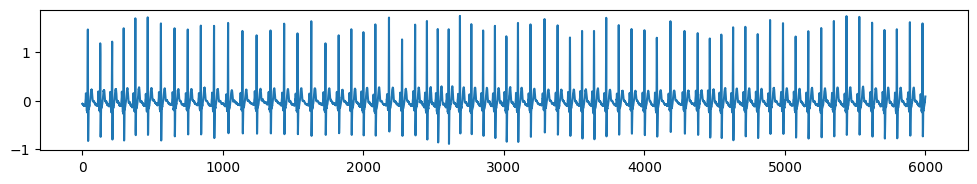

In [ ]:
file_name = '1D Exercises/apnea-ecg-a01er-data.csv'
fs = 100  # sampling rate [Hz] of recorded signal
# -- LOAD TEST SIGNAL --
y = np.genfromtxt(file_name, usecols=(1,4), delimiter=r',', skip_header=1, )
y_ecg = y[:,0]
y_resp = y[:,1]
K = len(y)
k = np.arange(K) #creating array of integers from 0 to K-1 -> indices of samples


# plot signal
fig, axs = plt.subplots(1, 1, sharex='all', figsize=(10, 2))
fig.tight_layout()
axs.plot(k, y_ecg)

print("Filename:", file_name)
print("Number of loaded samples: ",K)
print("Total signal duration [s]: ", K/fs)
print("Signal shape and samples "+str(y_ecg.shape)+" : "+str(y))

### a) Find R Waves
To find the R wave (the positive peak of the QRS comples), we use find_peaks() from scipy.signal. 

I set a distance, because it detected 1044 peaks, which is not what we want to achieve. With "normal" physiological heart rates of ca. 60-80 bpm and a sample of 1minute, we expect something more or less in this range. I adjusted the distance until I got an appropriate number of peaks. The distance measures the required minimal horizontal distance (>= 1) in samples between neighbouring peaks.

To find a good distance, we can calculate Minimum Distance (samples)= Sampling Rate (Hz) / Maximum Expected Heart Rate (Hz).
So in our case, this could be 100 / (80/60). We divide by 60 to convert bpm to Hz (= per second), because this is the SI unit. This gives me a distance of 75, with which I achieve the 67 peaks. 
​


In [28]:
y_peaks = find_peaks(y_ecg, height=None, distance=75)
nof_peaks = len(y_peaks[0])


print("Indices of minima: ", y_peaks[0])
print("Total number of peaks found: ",nof_peaks)
if nof_peaks == 0:
    print("No maxima found. Exit.")
    exit()

Indices of minima:  [  39  127  212  294  377  465  559  656  750  843  937 1037 1139 1240
 1339 1436 1531 1629 1730 1824 1914 2000 2085 2182 2275 2368 2452 2529
 2607 2687 2768 2852 2936 3017 3100 3189 3289 3382 3470 3556 3641 3728
 3817 3908 4000 4088 4185 4285 4379 4465 4547 4631 4718 4806 4894 4986
 5076 5166 5258 5348 5438 5529 5620 5708 5796 5889 5979]
Total number of peaks found:  67


### b) Calculate R-R intervals
Now I compute the R-R intervals between the peaks detected in the previous exercise. 
I look at the intervals in terms of samples between the peaks, secons between the peaks, and amplitudes of the R peaks.

1. R-R intervals in samples: calculated by difference between peak indices from 1-1a -> necessary for calculating 2 
2. R-R in seconds: we divide R-R in samples by the sampling frequenzy (100Hz) to get the amount of time passed between each peak (in seconds -> SI units)
3. Amplitude: computed through value of the signal (y_ecg) at the index (y_peaks[0])


In [18]:
# 1. R-R intervals in samples
rr_intervals = np.diff(y_peaks[0])

# 2. R-R intervals in seconds
rr_intervals_time = rr_intervals / fs  

# 3. R peak amplitudes
r_peak_amplitudes = y_ecg[y_peaks[0]]


# Print results
print("R-R Intervals (in samples):", rr_intervals)
print("R-R Intervals (in seconds):", rr_intervals_time)
print("R Peak Amplitudes:", r_peak_amplitudes)


R-R Intervals (in samples): [ 88  85  82  83  88  94  97  94  93  94 100 102 101  99  97  95  98 101
  94  90  86  85  97  93  93  84  77  78  80  81  84  84  81  83  89 100
  93  88  86  85  87  89  91  92  88  97 100  94  86  82  84  87  88  88
  92  90  90  92  90  90  91  91  88  88  93  90]
R-R Intervals (in seconds): [0.88 0.85 0.82 0.83 0.88 0.94 0.97 0.94 0.93 0.94 1.   1.02 1.01 0.99
 0.97 0.95 0.98 1.01 0.94 0.9  0.86 0.85 0.97 0.93 0.93 0.84 0.77 0.78
 0.8  0.81 0.84 0.84 0.81 0.83 0.89 1.   0.93 0.88 0.86 0.85 0.87 0.89
 0.91 0.92 0.88 0.97 1.   0.94 0.86 0.82 0.84 0.87 0.88 0.88 0.92 0.9
 0.9  0.92 0.9  0.9  0.91 0.91 0.88 0.88 0.93 0.9 ]
R Peak Amplitudes: [1.47  1.185 1.22  1.495 1.7   1.72  1.595 1.495 1.47  1.55  1.545 1.605
 1.44  1.35  1.45  1.59  1.39  1.64  1.185 1.35  1.475 1.415 1.575 1.715
 1.265 1.57  1.645 1.48  1.475 1.75  1.58  1.45  1.545 1.33  1.605 1.575
 1.685 1.555 1.305 1.44  1.44  1.71  1.56  1.48  1.455 1.3   1.64  1.44
 1.395 1.285 1.365 1.515 1.525

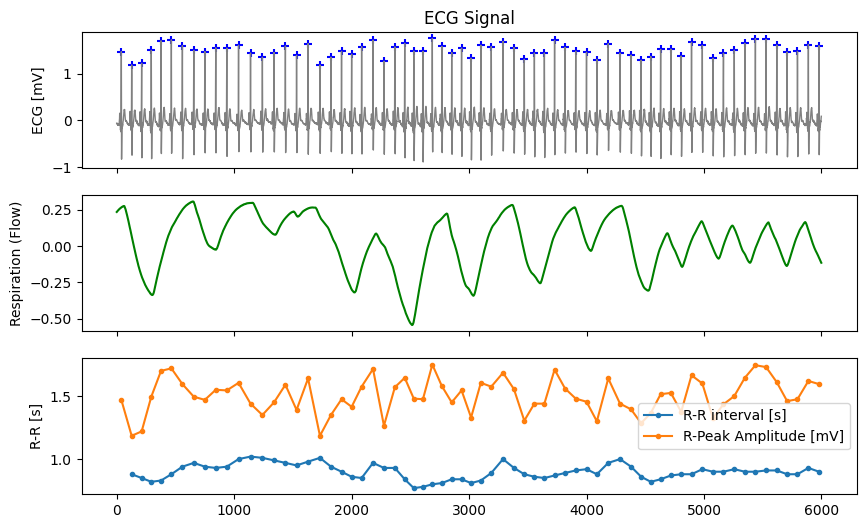

In [39]:
fig, axs = plt.subplots(3, 1, sharex='all', figsize=(10, 6))
axs[0].plot(k, y_ecg, lw=1.0, color='gray')
axs[0].scatter(y_peaks[0], y_ecg[y_peaks[0]], c='b', marker='+')
axs[0].set_title("ECG Signal")
axs[0].set_ylabel('ECG [mV]')

axs[1].plot(k, y_resp, 'g-', label='Respiration')
axs[1].set_ylabel('Respiration (Flow)')

axs[2].plot(y_peaks[0][1:], rr_intervals_time, '.-', label='R-R interval [s]')
axs[2].plot(y_peaks[0], r_peak_amplitudes, '.-', label='R-Peak Amplitude [mV]')
axs[2].set_ylabel('R-R [s]')
axs[2].legend()

plt.show()

## 1-2 ECG vs. Breathing
This exercise is to check whether we can observe the offect of the correlation between breathing activity and the ECG changes (R-R Intervals & QRS peak amplitudes).

1) scatter plots: R-R interval vs. Respiration & R peak amplitude vs. Respiration
2) add linear regression line
3) correlation coefficients

### 1 & 2: Scatter Plots & Linear Regression Line
Next, I plot the two plots and fit the regression line for each.

In the first step, I need to sample the respiration values at the peaks for the scatter plot.

In [59]:
respiration_values = [y_resp[idx] for idx in y_peaks[0]]

#### Linear Regression
Fitting the regression line (y = mx +b) for the two plots.

In [60]:
from scipy.stats import linregress

# Linear regression of R-R intervals vs. respiration signal
slope_rr, intercept_rr, r_value_rr, _, _ = linregress(respiration_values[1:], rr_intervals_time)
regression_line_rr = [slope_rr * x + intercept_rr for x in respiration_values]

# Linear regression of R peak amplitudes vs. respiration signal
slope_amp, intercept_amp, r_value_amp, _, _ = linregress(respiration_values, r_peak_amplitudes)
regression_line_amp = [slope_amp * x + intercept_amp for x in respiration_values]


#### Plot 1: R-R Interval vs. Respiration
This graph plots the R-R Interval vs. the Respiration. The regression coefficient of the regression line is 0.71, which indicates a moderate to strong positive linear correlation.

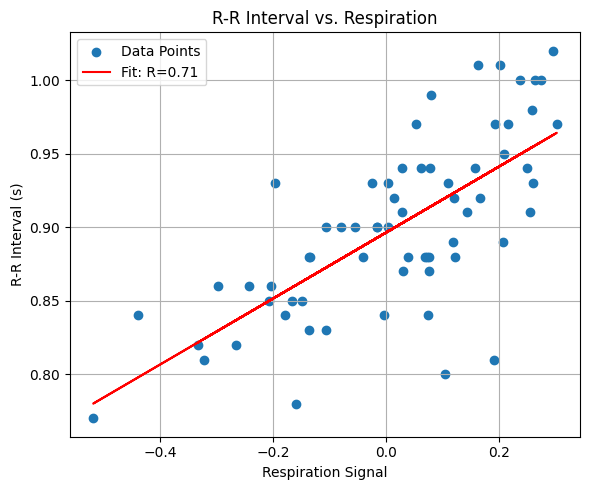

In [63]:
# Plot 1: R-R Interval vs. Respiration
plt.figure(figsize=(6, 5))
plt.scatter(respiration_values[1:], rr_intervals_time, label="Data Points")
plt.plot(respiration_values, regression_line_rr, color="red", label=f"Fit: R={r_value_rr:.2f}")
plt.xlabel("Respiration Signal")
plt.ylabel("R-R Interval (s)")
plt.title("R-R Interval vs. Respiration")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


#### Plot 2: R Peak Amplitude vs. Respiration
This graph plots the R-R Interval vs. the Respiration. The regression coefficient of the regression line is 0.18, which indicates a very weak positive linear correlation.

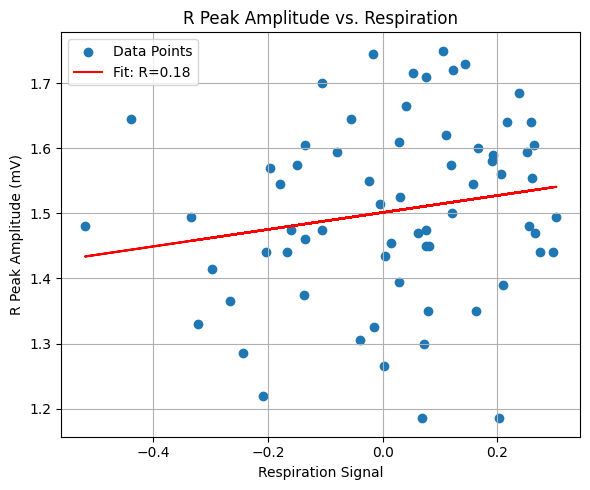

In [64]:
plt.figure(figsize=(6, 5))
plt.scatter(respiration_values, r_peak_amplitudes, label="Data Points")
plt.plot(respiration_values, regression_line_amp, color="red", label=f"Fit: R={r_value_amp:.2f}")
plt.xlabel("Respiration Signal")
plt.ylabel("R Peak Amplitude (mV)")
plt.title("R Peak Amplitude vs. Respiration")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()